In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))

# <span style="color:red"> ch7.시계열분석 </span>
# 1. 패키지 import 

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# 한글설정
plt.rc('font', family='Malgun Gothic')  # 윈도우즈
plt.rc('axes', unicode_minus=False) # 축의 깨짐 방지

In [4]:
df = pd.read_csv('data/일별평균대기오염도_2022(에어코리아).csv', encoding='cp949')
df

,측정일시,측정소명,이산화질소농도(ppm),오존농도(ppm),일산화탄소농도(ppm),아황산가스농도(ppm),미세먼지농도(㎍/㎥),초미세먼지농도(㎍/㎥)
0,20220101,강남구,0.029,0.014,0.5,0.003,25.0,12.0
1,20220101,홍릉로,0.038,0.009,0.6,0.004,27.0,16.0
2,20220101,행주,0.034,0.012,0.7,0.004,27.0,16.0
3,20220101,항동,0.030,0.011,0.5,0.003,27.0,14.0
4,20220101,한강대로,0.037,0.011,0.6,0.003,34.0,14.0
...,...,...,...,...,...,...,...,...
18245,20221231,구로구,0.037,0.009,0.5,0.004,43.0,29.0
18246,20221231,광진구,0.026,0.005,0.8,0.003,44.0,34.0
18247,20221231,관악산,0.008,0.038,0.3,0.005,29.0,18.0
18248,20221231,관악구,0.045,0.009,0.7,0.003,42.0,28.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18250 entries, 0 to 18249
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   측정일시          18250 non-null  int64  
 1   측정소명          18250 non-null  object 
 2   이산화질소농도(ppm)  18172 non-null  float64
 3   오존농도(ppm)     18176 non-null  float64
 4   일산화탄소농도(ppm)  18174 non-null  float64
 5   아황산가스농도(ppm)  18176 non-null  float64
 6   미세먼지농도(㎍/㎥)   18115 non-null  float64
 7   초미세먼지농도(㎍/㎥)  18122 non-null  float64
dtypes: float64(6), int64(1), object(1)
memory usage: 1.1+ MB


In [10]:
# 20220101 => "2022-01-01" => datetime 형으로 형 변환
df['측정일'] = df['측정일시'].astype(str)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18250 entries, 0 to 18249
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   측정일시          18250 non-null  int64  
 1   측정소명          18250 non-null  object 
 2   이산화질소농도(ppm)  18172 non-null  float64
 3   오존농도(ppm)     18176 non-null  float64
 4   일산화탄소농도(ppm)  18174 non-null  float64
 5   아황산가스농도(ppm)  18176 non-null  float64
 6   미세먼지농도(㎍/㎥)   18115 non-null  float64
 7   초미세먼지농도(㎍/㎥)  18122 non-null  float64
 8   측정일           18250 non-null  object 
dtypes: float64(6), int64(1), object(2)
memory usage: 1.3+ MB


In [16]:
df['측정일'] = df['측정일'].str[:4]+'-'+df['측정일'].str[4:6]+'-'+df['측정일'].str[-2:]

In [24]:
df['측정일'] = pd.to_datetime(df['측정일'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18250 entries, 0 to 18249
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   측정일시          18250 non-null  int64         
 1   측정소명          18250 non-null  object        
 2   이산화질소농도(ppm)  18172 non-null  float64       
 3   오존농도(ppm)     18176 non-null  float64       
 4   일산화탄소농도(ppm)  18174 non-null  float64       
 5   아황산가스농도(ppm)  18176 non-null  float64       
 6   미세먼지농도(㎍/㎥)   18115 non-null  float64       
 7   초미세먼지농도(㎍/㎥)  18122 non-null  float64       
 8   측정일           18250 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(6), int64(1), object(1)
memory usage: 1.3+ MB


In [25]:
df.columns

Index(['측정일시', '측정소명', '이산화질소농도(ppm)', '오존농도(ppm)', '일산화탄소농도(ppm)',
       '아황산가스농도(ppm)', '미세먼지농도(㎍/㎥)', '초미세먼지농도(㎍/㎥)', '측정일'],
      dtype='object')

In [26]:
# 컬럼 순서 바꾸기 - 측정일을 앞으로 옮기고 싶다
# 리스트로 바꾸기 -> 옮길 열을 삭제하고 옮겨서 정렬하기
cols = df.columns.tolist()
cols.remove('측정일')
cols

['측정일시',
 '측정소명',
 '이산화질소농도(ppm)',
 '오존농도(ppm)',
 '일산화탄소농도(ppm)',
 '아황산가스농도(ppm)',
 '미세먼지농도(㎍/㎥)',
 '초미세먼지농도(㎍/㎥)']

In [27]:
new_cols = [cols[0], '측정일'] + cols[1:]

In [31]:
print(new_cols)

['측정일시', '측정일', '측정소명', '이산화질소농도(ppm)', '오존농도(ppm)', '일산화탄소농도(ppm)', '아황산가스농도(ppm)', '미세먼지농도(㎍/㎥)', '초미세먼지농도(㎍/㎥)']


In [32]:
df = df[new_cols]
df

,측정일시,측정일,측정소명,이산화질소농도(ppm),오존농도(ppm),일산화탄소농도(ppm),아황산가스농도(ppm),미세먼지농도(㎍/㎥),초미세먼지농도(㎍/㎥)
0,20220101,2022-01-01,강남구,0.029,0.014,0.5,0.003,25.0,12.0
1,20220101,2022-01-01,홍릉로,0.038,0.009,0.6,0.004,27.0,16.0
2,20220101,2022-01-01,행주,0.034,0.012,0.7,0.004,27.0,16.0
3,20220101,2022-01-01,항동,0.030,0.011,0.5,0.003,27.0,14.0
4,20220101,2022-01-01,한강대로,0.037,0.011,0.6,0.003,34.0,14.0
...,...,...,...,...,...,...,...,...,...
18245,20221231,2022-12-31,구로구,0.037,0.009,0.5,0.004,43.0,29.0
18246,20221231,2022-12-31,광진구,0.026,0.005,0.8,0.003,44.0,34.0
18247,20221231,2022-12-31,관악산,0.008,0.038,0.3,0.005,29.0,18.0
18248,20221231,2022-12-31,관악구,0.045,0.009,0.7,0.003,42.0,28.0


In [35]:
# 서울시 측정소명들
print('측정소명 개수 : ', len(df['측정소명'].unique()))
print(df['측정소명'].unique())

측정소명 개수 :  50
['강남구' '홍릉로' '행주' '항동' '한강대로' '청계천로' '천호대로' '중랑구' '중구' '종로구' '종로' '정릉로'
 '자연사박물관' '은평구' '용산구' '올림픽공원' '영등포로' '영등포구' '양천구' '신촌로' '시흥대로' '송파구' '세곡'
 '성북구' '성동구' '화랑로' '서초구' '서울숲' '서대문구' '북한산' '마포아트센터' '마포구' '동작대로' '동작구'
 '동대문구' '도산대로' '도봉구' '노원구' '남산' '금천구' '구로구' '광진구' '관악산' '관악구' '공항대로' '강서구'
 '강북구' '강변북로' '강동구' '강남대로']


In [42]:
loc_name = '공항대로'
df_flt = df[df['측정소명']==loc_name]
df_flt

,측정일시,측정일,측정소명,이산화질소농도(ppm),오존농도(ppm),일산화탄소농도(ppm),아황산가스농도(ppm),미세먼지농도(㎍/㎥),초미세먼지농도(㎍/㎥)
44,20220101,2022-01-01,공항대로,0.035,0.010,0.6,0.002,31.0,15.0
93,20220102,2022-01-02,공항대로,0.027,0.017,0.5,0.003,37.0,22.0
143,20220103,2022-01-03,공항대로,0.041,0.007,0.6,0.003,31.0,18.0
196,20220104,2022-01-04,공항대로,0.032,0.010,0.5,0.003,48.0,21.0
244,20220105,2022-01-05,공항대로,0.045,0.004,0.8,0.003,56.0,34.0
...,...,...,...,...,...,...,...,...,...
18043,20221227,2022-12-27,공항대로,0.051,0.004,0.9,0.003,51.0,37.0
18095,20221228,2022-12-28,공항대로,0.034,0.012,0.5,0.003,44.0,21.0
18143,20221229,2022-12-29,공항대로,0.040,0.007,0.6,0.003,35.0,21.0
18193,20221230,2022-12-30,공항대로,0.037,0.011,0.6,0.003,40.0,27.0


In [43]:
df_flt.isna().sum()

측정일시            0
측정일             0
측정소명            0
이산화질소농도(ppm)    0
오존농도(ppm)       0
일산화탄소농도(ppm)    0
아황산가스농도(ppm)    0
미세먼지농도(㎍/㎥)     0
초미세먼지농도(㎍/㎥)    0
dtype: int64

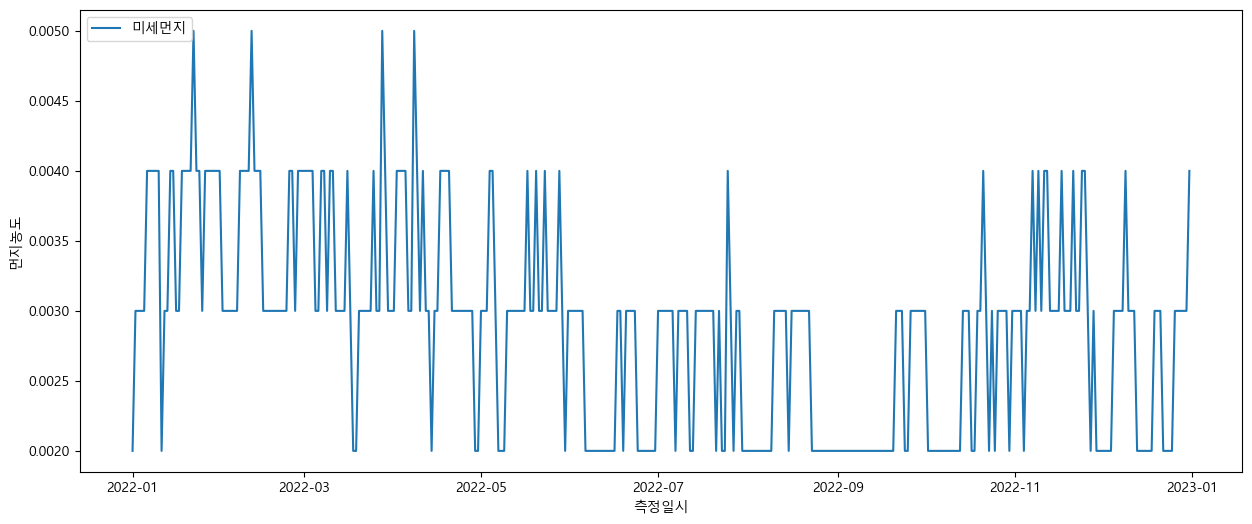

In [71]:
plt.figure(figsize=(15,6))
plt.plot(df_flt['측정일'], df_flt['아황산가스농도(ppm)'], label='미세먼지' )
# plt.plot(df_flt['측정일'], df_flt['초미세먼지농도(㎍/㎥)'], label='초미세먼지' )
plt.xlabel('측정일시')
plt.ylabel('먼지농도')
plt.legend(loc='upper left')
plt.show()

In [59]:
import numpy as np

In [62]:
df.groupby('측정소명',axis=0).count()

,측정일시,측정일,이산화질소농도(ppm),오존농도(ppm),일산화탄소농도(ppm),아황산가스농도(ppm),미세먼지농도(㎍/㎥),초미세먼지농도(㎍/㎥)
측정소명,,,,,,,,
강남구,365,365,365,365,365,365,365,365
강남대로,365,365,365,365,365,365,365,365
강동구,365,365,365,365,365,365,365,365
강변북로,365,365,365,365,365,365,361,365
강북구,365,365,365,365,365,365,365,365
강서구,365,365,365,365,365,365,365,365
공항대로,365,365,365,365,365,365,365,365
관악구,365,365,363,363,363,363,363,363
관악산,365,365,362,365,365,365,355,365


In [66]:
# 결측치 없는 측정소만 추출
clean_stations = (
    df.groupby('측정소명')                          # 측정소별로 그룹화
      .filter(lambda group: not group.isnull().any().any())  # NaN이 하나라도 있으면 제외
)

# 결과 확인
print(clean_stations['측정소명'].unique(), len(clean_stations['측정소명'].unique()), len(df['측정소명'].unique()))

['강남구' '홍릉로' '청계천로' '천호대로' '중랑구' '중구' '종로구' '종로' '정릉로' '자연사박물관' '용산구'
 '영등포로' '영등포구' '양천구' '신촌로' '성동구' '화랑로' '서울숲' '마포구' '도봉구' '노원구' '금천구' '구로구'
 '광진구' '공항대로' '강서구' '강북구' '강동구' '강남대로'] 29 50


In [64]:
clean_stations

,측정일시,측정일,측정소명,이산화질소농도(ppm),오존농도(ppm),일산화탄소농도(ppm),아황산가스농도(ppm),미세먼지농도(㎍/㎥),초미세먼지농도(㎍/㎥)
0,20220101,2022-01-01,강남구,0.029,0.014,0.5,0.003,25.0,12.0
1,20220101,2022-01-01,홍릉로,0.038,0.009,0.6,0.004,27.0,16.0
5,20220101,2022-01-01,청계천로,0.037,0.011,0.6,0.003,27.0,16.0
6,20220101,2022-01-01,천호대로,0.038,0.009,0.6,0.004,38.0,17.0
7,20220101,2022-01-01,중랑구,0.028,0.017,0.4,0.003,25.0,12.0
...,...,...,...,...,...,...,...,...,...
18242,20221231,2022-12-31,노원구,0.057,0.006,0.9,0.004,47.0,36.0
18244,20221231,2022-12-31,금천구,0.035,0.012,0.6,0.003,35.0,29.0
18245,20221231,2022-12-31,구로구,0.037,0.009,0.5,0.004,43.0,29.0
18246,20221231,2022-12-31,광진구,0.026,0.005,0.8,0.003,44.0,34.0


In [74]:
df_flt2 = df_flt[['측정일', '미세먼지농도(㎍/㎥)']]
ts = df_flt2.set_index('측정일') # 독립변수를 인덱스로 설정해야 한다
ts.head()

,미세먼지농도(㎍/㎥)
측정일,
2022-01-01,31.0
2022-01-02,37.0
2022-01-03,31.0
2022-01-04,48.0
2022-01-05,56.0


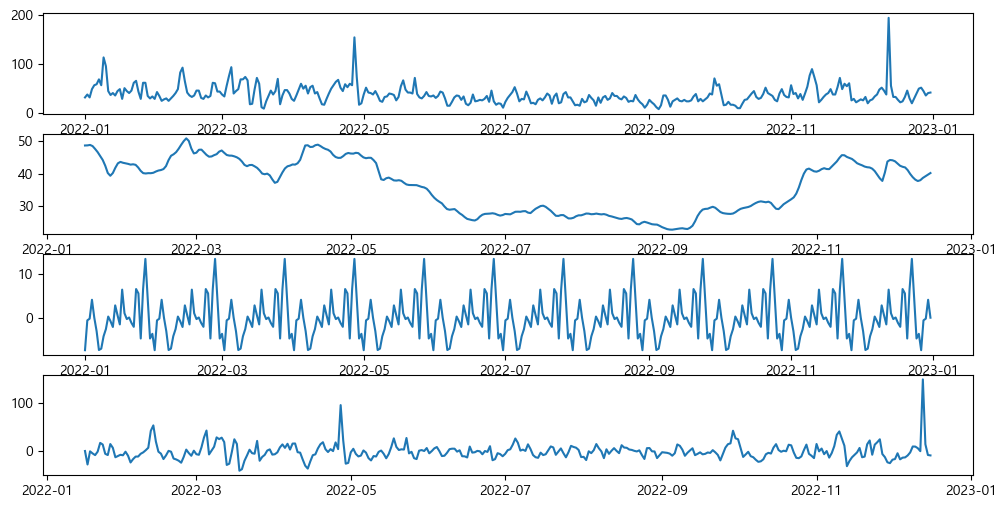

In [82]:
# 시계역 데이터의 구조를 분해해주는 도구(구조 분석만해준다. 예측은 되지 않음)
# 추세
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(ts['미세먼지농도(㎍/㎥)'],
                           model='additive',  # 실제값 추세, 계절성, 잔차를 덧셈으로 분석
                            period=30)
# result 는 결과 전달 객체
# result.observed : 실제데이터
# result.seasonal : 주기적인 계절성 패턴
# result.trend    : 데이터의 장기적인 변화, 전반적으로 감소, 증가
# result.resid    : 잔차(노이즈)

fig, axes = plt.subplots(4,1, figsize=(12,6))
axes[0].plot(result.observed)
axes[1].plot(result.trend)
axes[2].plot(result.seasonal)
axes[3].plot(result.resid)

In [85]:
def plot_seasonal_decompose(result):
    fig, axes = plt.subplots(4,1, figsize=(12,6))
    result.observed.plot(ax=axes[0])
    axes[0].set_ylabel('관측값')
    axes[1].plot(result.trend)
    axes[0].set_ylabel('트렌드')
    axes[2].plot(result.seasonal)
    axes[0].set_ylabel('계절성')
    axes[3].plot(result.resid)
    axes[0].set_ylabel('잔차')
    plt.xlabel('날짜')
    plt.tight_layout()
    plt.show()

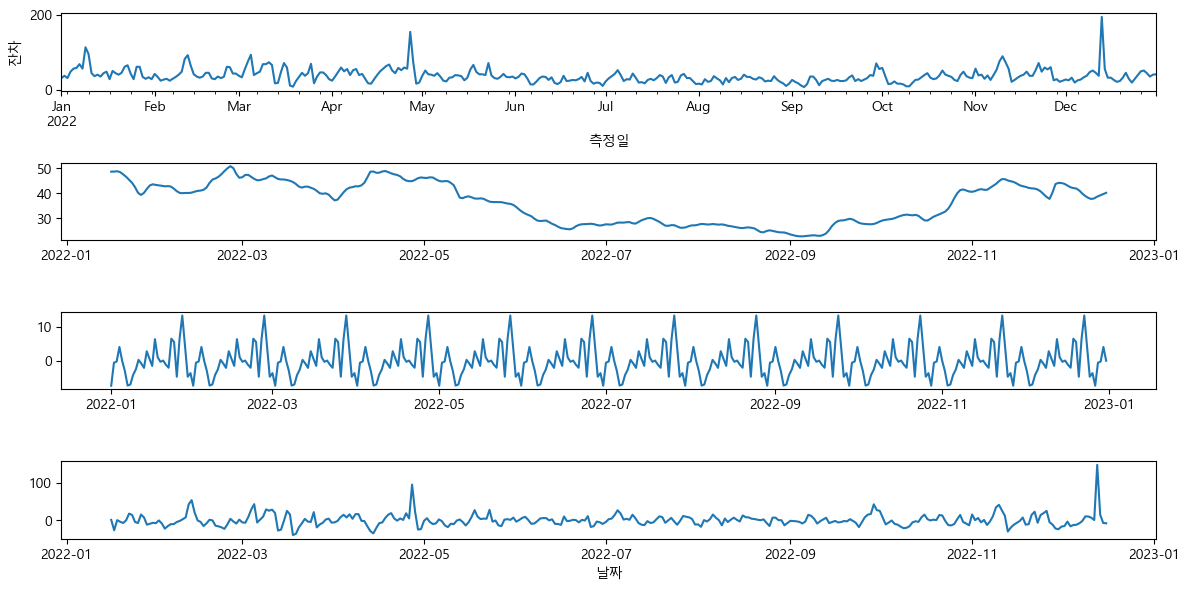

In [86]:
plot_seasonal_decompose(result)

## seasonal_decompose & RNN/LSTM/GRU & Prophet
        통계적 분석                       예측                    예측
## Prophet
- 계절성, 추세, 휴일효과 등을 자동으로 모델링
- pip install prophet

In [88]:
df_flt2.columns = ['ds', 'y']  # prophet의 fit시 컬럼명을 ds, y 
df_flt2

,ds,y
44,2022-01-01,31.0
93,2022-01-02,37.0
143,2022-01-03,31.0
196,2022-01-04,48.0
244,2022-01-05,56.0
...,...,...
18043,2022-12-27,51.0
18095,2022-12-28,44.0
18143,2022-12-29,35.0
18193,2022-12-30,40.0


In [89]:
from prophet import Prophet
p = Prophet()
p.fit(df_flt2)

16:49:50 - cmdstanpy - INFO - Chain [1] start processing
16:49:50 - cmdstanpy - INFO - Chain [1] done processing


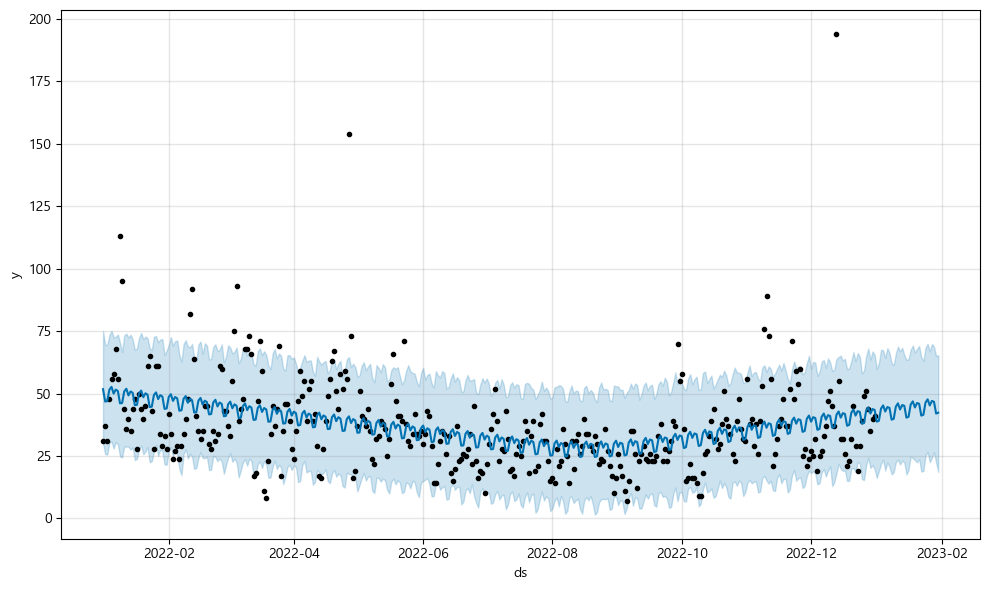

In [94]:
# p모델을 이용하여 30일 이후의 데이터를 예측
future = p.make_future_dataframe(periods=30)
forcast = p.predict(future)
f = p.plot(forcast)

In [97]:
forcast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(30)

,ds,yhat,yhat_lower,yhat_upper
365,2023-01-01,38.738106,16.178017,59.869952
366,2023-01-02,39.108625,18.962293,62.198531
367,2023-01-03,43.966852,21.838591,67.578907
368,2023-01-04,45.272123,23.553010,67.327897
369,2023-01-05,42.812810,19.174138,64.288327
370,2023-01-06,44.613248,22.370823,68.230286
371,2023-01-07,44.275744,20.647039,66.349436
372,2023-01-08,39.550766,17.657499,62.197527
373,2023-01-09,39.921285,18.524782,61.401677
374,2023-01-10,44.779513,22.543573,66.097345


In [99]:
forcast.loc[forcast['ds']=='2023-01-06', ['yhat', 'yhat_lower', 'yhat_upper']]

,yhat,yhat_lower,yhat_upper
370,44.613248,22.370823,68.230286
